# Customer Behaviour Analysis

## Initialize Spark Session

In [1]:
# Libraries and packages used in the implementation code
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import *
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.evaluation import *
import matplotlib.pyplot as plt
import seaborn as sns

# Initialise Spark Session
spark = SparkSession.builder \
    .appName("CustomerSegmentation") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

## Load Data from HDFS

In [2]:
import pandas as pd

# Read both sheets and combine
df1 = pd.read_excel('/home/jovyan/work/data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('/home/jovyan/work/data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

In [3]:
# Combine datasets
df = pd.concat([df1, df2], ignore_index=True)

In [4]:
print(f"{len(df)} records")

1067371 records


In [5]:
# Read Excel
import pandas as pd
import numpy as np

# Read both sheets (2009-2010, 2010-2011)
df1 = pd.read_excel('/home/jovyan/work/data/online_retail_II.xlsx', 
                   sheet_name='Year 2009-2010',
                   dtype={'StockCode': str, 'CustomerID': str, 'Invoice': str})

df2 = pd.read_excel('/home/jovyan/work/data/online_retail_II.xlsx', 
                   sheet_name='Year 2010-2011',
                   dtype={'StockCode': str, 'CustomerID': str, 'Invoice': str})

print(f"Sheet 1 records: {len(df1)}")
print(f"Sheet 2 records: {len(df2)}")

# Combine both sheets into one dataset
combined_df = pd.concat([df1, df2], ignore_index=True)
print(f"Combined dataset: {len(combined_df)} records")

Sheet 1 records: 525461
Sheet 2 records: 541910
Combined dataset: 1067371 records


In [6]:
# Data Cleaning 
# Handle missing values and ensure correct data type formats
combined_df['Customer ID'] = combined_df['Customer ID'].fillna('0').astype(str)
combined_df['StockCode'] = combined_df['StockCode'].astype(str)
combined_df['Invoice'] = combined_df['Invoice'].astype(str)
combined_df['Description'] = combined_df['Description'].fillna('Unknown')

In [7]:
# Convert Excel dataset to Spark DataFrame
from pyspark.sql.types import *

# Define schema to ensure correct data type formats in Spark DataFrame
schema = StructType([
    StructField("Invoice", StringType(), True),
    StructField("StockCode", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Quantity", IntegerType(), True),
    StructField("InvoiceDate", TimestampType(), True),
    StructField("Price", DoubleType(), True),
    StructField("Customer ID", StringType(), True),
    StructField("Country", StringType(), True)
])

# Create Spark DataFrame with predetermined schema
sparkdf = spark.createDataFrame(combined_df, schema=schema)

print("Spark DataFrame Overview:")
print(f"Records: {sparkdf.count()}")
sparkdf.printSchema()
sparkdf.show(5, truncate=False)

Spark DataFrame Overview:
Records: 1067371
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Country: string (nullable = true)

+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|Description                        |Quantity|InvoiceDate        |Price|Customer ID|Country       |
+-------+---------+-----------------------------------+--------+-------------------+-----+-----------+--------------+
|489434 |85048    |15CM CHRISTMAS GLASS BALL 20 LIGHTS|12      |2009-12-01 07:45:00|6.95 |13085.0    |United Kingdom|
|489434 |79323P   |PINK CHERRY LIGHTS                 |12      |2009-12-01 07:45:00|6.75 |13085.0    |United Kingdom|
|489434 |79323W   | WHITE CHERRY

#### 

## Data Preprocessing

1. Remove records with no valid customer ID, since it could distort estimates and results when include unidentified customers for analysis.
2. Remove transactions with negative quantities and prices that represent returns, refunds, or cancellations rather than actual purchasing behavior.
3. Invoices start with C indicate cancellations, and in this case the analysis requires complete transactions.

In [8]:
# Show all column names
print("Column names:", sparkdf.columns)

# Data Cleaning
cleaned_df = sparkdf.filter(
    (col("Customer ID").isNotNull()) &
    (col("Quantity") > 0) &
    (col("Price") > 0) &
    (~col("Invoice").startswith("C"))  # Remove cancellations
)

print(f"Original records: {sparkdf.count()}")
print(f"Cleaned records: {cleaned_df.count()}")
print(f"Records removed: {sparkdf.count() - cleaned_df.count()}")

# Show sample of cleaned data
cleaned_df.show(10)

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Original records: 1067371
Cleaned records: 1041670
Records removed: 25701
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|RECORD FRAME 7" S...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|Un

In [9]:
# Data Quality
print("\nData Quality:")
print(f"Total records: {cleaned_df.count()}")
# print(f"Records with Customer ID: {cleaned_df.filter(col('Customer ID') != '0').count()}")
print(f"Records with null: {cleaned_df.filter(col('Description').isNull()).count()}")
print(f"Percentage of data removed: {(sparkdf.count() - cleaned_df.count()) * 100 / sparkdf.count()}%")

# Summary Statistics
print("\nSummary Statistics:")
cleaned_df.describe(['Quantity', 'Price']).show()


Data Quality:
Total records: 1041670
Records with null: 0
Percentage of data removed: 2.407878797531505%

Summary Statistics:
+-------+------------------+------------------+
|summary|          Quantity|             Price|
+-------+------------------+------------------+
|  count|           1041670|           1041670|
|   mean|10.963457716935306| 4.076683295090127|
| stddev|126.51499031214175|51.447729542300465|
|    min|                 1|             0.001|
|    max|             80995|          25111.09|
+-------+------------------+------------------+



Since the dataset is large, removing 2.4% of missing data is reasonable and considered to have negligible impact.

## Feature Engineering for RFM Analysis (Recency, Frequency, Monetary)

The data shows which customer bought what items, how many items, and on what date. However, it is possible to make use of the current features to create more useful features such as Recency, Frequency, and Monetary for RFM Analysis to summarise historical behaviours of customers that have interacted with the retail store. RFM features would offer more clarity in the insights and results for the following analytical tasks. 

In [10]:
# Convert date and calculate features
from pyspark.sql.functions import to_timestamp, datediff, lit, max, countDistinct, sum

feature_df = cleaned_df.withColumn(
    "TotalSales", col("Quantity") * col("Price")
).withColumn(
    "InvoiceDate", to_timestamp(col("InvoiceDate"), "yyyy-MM-dd HH:mm:ss")
)

# Calculate RFM features
from pyspark.sql.window import Window

# Recency: Days since last purchase of each customer
max_date = feature_df.agg(max("InvoiceDate")).collect()[0][0]

recency_df = feature_df.groupBy("Customer ID").agg(
    max("InvoiceDate").alias("LastPurchaseDate")
).withColumn(
    "Recency", datediff(lit(max_date), col("LastPurchaseDate"))
)

# Frequency: Number of invoices with distinct dates of each customer
frequency_df = feature_df.groupBy("Customer ID").agg(
    countDistinct("Invoice").alias("Frequency")
)

# Monetary: Total spending of each customer
monetary_df = feature_df.groupBy("Customer ID").agg(
    sum("TotalSales").alias("Monetary")
)

# Combine RFM features
rfm_df_combined = recency_df.join(frequency_df, "Customer ID") \
    .join(monetary_df, "Customer ID") \
    .select("Customer ID", "Recency", "Frequency", "Monetary")

print('RFM Features Sample:')
rfm_df_combined.show(10)

print(f"RFM dataset size: {rfm_df_combined.count()} unique customers")

RFM Features Sample:
+-----------+-------+---------+------------------+
|Customer ID|Recency|Frequency|          Monetary|
+-----------+-------+---------+------------------+
|    16939.0|    488|        3|             449.0|
|    15039.0|      9|       93| 40031.42999999993|
|    17966.0|     37|       10|           1974.42|
|    12891.0|    185|       11|             840.5|
|    17955.0|    198|        6|             949.9|
|    13178.0|     26|       21|          14059.19|
|    16553.0|    163|       33|          16644.01|
|    13259.0|     61|        9|1433.3800000000012|
|    16917.0|    276|        2|1857.8300000000004|
|    15141.0|    457|        7|           1388.47|
+-----------+-------+---------+------------------+
only showing top 10 rows

RFM dataset size: 5879 unique customers


In [11]:
# Remove outlier
def remove_outlier(rfm_df_combined):
    """Remove outliers from RFM features comprehensively"""
    print(f"Original customer count: {rfm_df_combined.count()}")
    
    # Remove extreme monetary outliers
    initial_count = rfm_df_combined.count()
    rfm_clean = rfm_df_combined.filter(col("Monetary") < 1000000)  # Remove extreme values
    print(f"After removing extreme monetary: {rfm_clean.count()}")
    
    return rfm_clean

rfm_df = remove_outlier(rfm_df_combined)

Original customer count: 5879
After removing extreme monetary: 5878


## The Four Analytical Tasks

1. Clustering (Customer Segmentation): "Who are my different types of customers?"

2. Regression (Customer Lifetime Value): "How much expected revenue that the retail store can earn from a customer throughout their lifetime?"

3. Classification (Churn Prediction): "Which customers are not returning?"

4. Association Rule Mining (Product Affinity): "Which products are frequently bought together by customers?"

## 1. Customer Segmentation K-Means Clustering with RFM (Unsupervised)

In [12]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import numpy as np

# Vector Assembler combine RFM column into a vector of features for Spark ML algorithms
assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],
    outputCol="features"
)
rfm_features = assembler.transform(rfm_df)

In [13]:
# Normalise Data
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)
scalerModel = scaler.fit(rfm_features)
rfm_scaled = scalerModel.transform(rfm_features)

Monetary generally has a high value (thousands) and Frequency generally has a low value (one to two digits). In this case normalisation of data is conducted to ensure that models would not be overshadowed by Monetary.

In [14]:
# Determine optimal k using elbow method
costs = []
silhouette_scores = []
evaluator = ClusteringEvaluator(
    predictionCol='prediction',
    featuresCol='scaledFeatures',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)

for k in range(2, 8):
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=3208)
    model = kmeans.fit(rfm_scaled)
    predictions = model.transform(rfm_scaled)
    
    # Use summary method to get training cost (WCSS)
    cost = model.summary.trainingCost
    costs.append(cost)
    
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    
    print(f"K={k}, Cost (WCSS)={cost:.2f}, Silhouette={silhouette:.4f}")

K=2, Cost (WCSS)=12530.03, Silhouette=0.4148
K=3, Cost (WCSS)=7134.07, Silhouette=0.7179
K=4, Cost (WCSS)=5471.39, Silhouette=0.7322
K=5, Cost (WCSS)=4033.56, Silhouette=0.7730
K=6, Cost (WCSS)=3560.95, Silhouette=0.7703
K=7, Cost (WCSS)=2846.20, Silhouette=0.7394


k = 5 have the highest silhouette score.

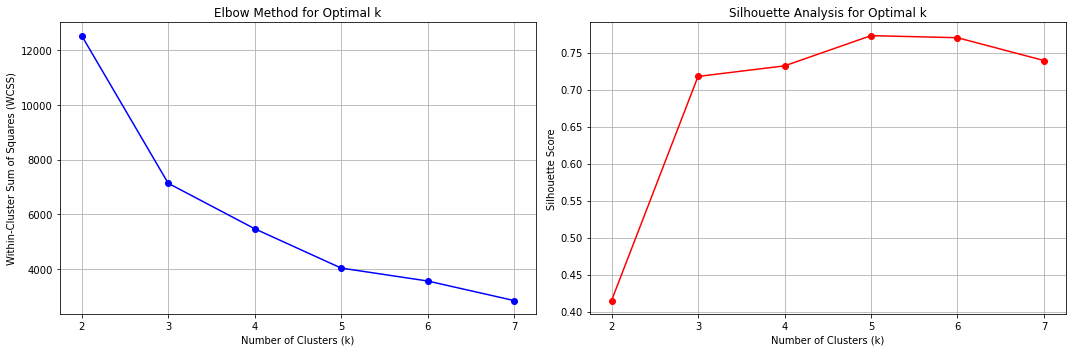

In [15]:
# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(range(2, 8), costs, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette scores
ax2.plot(range(2, 8), silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis for Optimal k')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Choose optimal k based on both metrics
optimal_k = 5

Optimal value of k is chosen based on: <br>
1. Where elbow curve shows significant bend, where it is the beginning of significant reduction in clustering improvement. <br>
2. Silhouette score is highest. <br>

In this case, the elbow falls on k = 5, and it also has the highest silhoutte score. <br>
Therefore, it is reasonable to conduct clustering with optimal value of k = 5.

In [17]:
# Clustering with optimal k
kmeans = KMeans(featuresCol='scaledFeatures', k=optimal_k, seed=3208)
kmeans_model = kmeans.fit(rfm_scaled)
clustered_rfm = kmeans_model.transform(rfm_scaled)

# Analyse cluster characteristics
cluster_profile = clustered_rfm.groupBy("prediction").agg(
    mean("Recency").alias("Avg_Recency"),
    mean("Frequency").alias("Avg_Frequency"),
    mean("Monetary").alias("Avg_Monetary"),
    count("Customer ID").alias("Count")
).orderBy("prediction")

print("Cluster Profiles:")
cluster_profile.show()

Cluster Profiles:
+----------+------------------+------------------+------------------+-----+
|prediction|       Avg_Recency|     Avg_Frequency|      Avg_Monetary|Count|
+----------+------------------+------------------+------------------+-----+
|         0| 72.56982167352538| 5.576131687242798| 2113.592892181072| 3645|
|         1|               0.5|             148.0| 568712.0849999993|    2|
|         2|25.581227436823106| 34.95667870036101| 19432.02614801444|  277|
|         3|              31.5|176.07142857142858|146863.41499999995|   14|
|         4|468.37628865979383|2.1649484536082473| 754.2267335051547| 1940|
+----------+------------------+------------------+------------------+-----+



| Cluster | Recency  | Frequency | Spending | Count |
|---------|----------|-----------|----------|-------|
| 0       | Medium   | Low       | Medium   | 3,645 | 
| 1       | Very Low | Very High | Very High| 2     | 
| 2       | Low      | Medium    | High     | 277   | 
| 3       | Medium   | High      | Very High| 14    | 
| 4       | Very High| Low       | Low      | 1,940 |

Cluster 0: Medium Recency, Low Frequency, Medium Spending <br>
Cluster 1: Very Low Recency, Extremely High Frequency, Extremely High Spending <br>
Cluster 2: Low Recency, Medium Frequency, High Spending <br>
Cluster 3: Medium Recency, High Frequency, EXtremely High Spending <br> 
Cluster 4: Very High Recency, Low Frequency, Low Spending

Cluster 0: Regular Customers. <br>
Cluster 1: Rare High Spending Customers that visited frequently and very recently. <br>
Cluster 2: Loyal Consistent High Spending Customers. <br>
Cluster 3: Rare High Spending Customers that visited frequently. <br> 
Cluster 4: Churned Customers.

## 2. Regression and Random Forest on Customer Lifetime Value (CLV) Prediction (Supervised)

In [18]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Create additional features for CLV prediction
clv_data = feature_df.groupBy("Customer ID").agg(
    sum("TotalSales").alias("TotalSpent"),
    countDistinct("Invoice").alias("TotalTransactions"),
    datediff(lit(max_date), min("InvoiceDate")).alias("CustomerTenure"),
    mean("Quantity").alias("AvgQuantity"),
    count("StockCode").alias("TotalProducts")
)

# Join with country information
country_data = feature_df.groupBy("Customer ID").agg(
    first("Country").alias("Country")
)

clv_data = clv_data.join(country_data, "Customer ID")

# Prepare features for regression
indexer = StringIndexer(inputCol="Country", outputCol="CountryIndex")

assembler_clv = VectorAssembler(
    inputCols=["TotalTransactions", "CustomerTenure", "AvgQuantity", "TotalProducts", "CountryIndex"],
    outputCol="features_clv"
)

In [19]:
# Split data
train_data, test_data = clv_data.randomSplit([0.8, 0.2], seed=3208)

In [20]:
# Prepare features for regression with handleInvalid parameter
indexer = StringIndexer(
    inputCol="Country", 
    outputCol="CountryIndex",
    handleInvalid="keep"  # This will assign unseen labels to a special index
)

assembler_clv = VectorAssembler(
    inputCols=["TotalTransactions", "CustomerTenure", "AvgQuantity", "TotalProducts", "CountryIndex"],
    outputCol="features_clv"
)

# Split data
train_data, test_data = clv_data.randomSplit([0.8, 0.2], seed=3208)

In [21]:
# Linear Regression
lr = LinearRegression(featuresCol="features_clv", labelCol="TotalSpent")

pipeline_lr = Pipeline(stages=[indexer, assembler_clv, lr])
lr_model = pipeline_lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

In [22]:
# Random Forest
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features_clv", 
    labelCol="TotalSpent", 
    numTrees=50, 
    maxBins=50,
    seed=3208
)

pipeline_rf = Pipeline(stages=[indexer, assembler_clv, rf])
rf_model = pipeline_rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

In [23]:
# Model Evaluation and Comparison
evaluator = RegressionEvaluator(labelCol="TotalSpent", predictionCol="prediction")

lr_rmse = evaluator.evaluate(lr_predictions)
rf_rmse = evaluator.evaluate(rf_predictions)

print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Linear Regression RMSE: 9556.47
Random Forest RMSE: 5821.85


Lower the Root Mean Square Error (RMSE), better the model performance. <br>
Since Random Forest have lower RMSE, Random Forest model would be the preferred model. 

In [24]:
# Show CLV predictions
print("Sample Predictions:")
rf_predictions.select("Customer ID", "TotalSpent", "prediction").show(10)

Sample Predictions:
+-----------+------------------+------------------+
|Customer ID|        TotalSpent|        prediction|
+-----------+------------------+------------------+
|    12347.0|           5633.32|25353.678449500218|
|    12350.0|334.40000000000003|1198.8893454766958|
|    12358.0|3887.0699999999997|1835.1011344233898|
|    12362.0|5356.2300000000005|15983.374427682344|
|    12377.0|3426.3199999999997| 2350.705932919153|
|    12387.0|            143.94| 772.1511949150013|
|    12394.0|           1272.48| 881.8235920756778|
|    12399.0|            1962.3|2092.9946223212846|
|    12412.0|           2596.93| 3565.006870881894|
|    12421.0|1098.6000000000001|1837.7000371894871|
+-----------+------------------+------------------+
only showing top 10 rows



In [25]:
# Random Forest Feature Importance
rf_model.stages[-1].featureImportances

SparseVector(5, {0: 0.2281, 1: 0.2172, 2: 0.3302, 3: 0.141, 4: 0.0835})

Average Quantity would be the most important feature for prediction according to Random Forest.

## 3. Customer Churn Classification

A stop date of 90 days before the end period date of the dataset is used to get RFM features before the stop date, then the actual churn results are collected from whether the customers have made at least one purchase or no purchases at all after the stop date. <br>
Classification model will then predict using past RFM features whether a customer is churned. 

"1" indicate **churned customers** that has not made any purchase from stop date till end period. <br>
"0" indicate customers that have made at least one purchase from stop date till end period.

In [26]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F
from sklearn.metrics import roc_curve, auc

# Define the key dates
stop_date = F.lit("2011-09-01").cast("date")
end_period = F.lit("2011-11-30").cast("date")

# Create RFM features from past data until a specific date
# If customer did not interact with store after this specific date till the end period (3 months), then considered as churned
features_past = cleaned_df.filter(F.col("InvoiceDate") < stop_date) \
    .groupBy("Customer ID") \
    .agg(
        F.datediff(stop_date, F.max("InvoiceDate")).alias("Recency_Past"),
        F.countDistinct("Invoice").alias("Frequency_Past"),
        F.sum(F.col("Quantity") * F.col("Price")).alias("Monetary_Past")
    )

A customer is considered active if at least one purchase was made by them between the stop date and the end period of the dataset.

In [27]:
label_future = cleaned_df.filter(
    (F.col("InvoiceDate") >= stop_date) & 
    (F.col("InvoiceDate") <= end_period)
).groupBy("Customer ID").agg(
    F.first("Customer ID").alias("future_active") 
)

A customer "churns" if they do NOT appear between the stop date and end period of the dataset.

In [28]:
all_customers = features_past.select("Customer ID")
churn_label = all_customers.join(F.broadcast(label_future), "Customer ID", "left_outer") \
    .withColumn("Churn", F.when(F.col("future_active").isNull(), 1).otherwise(0)) \
    .select("Customer ID", "Churn")

In [29]:
# Join all features
modeling_df = features_past.join(churn_label, "Customer ID")

print("Churn Distribution:")
modeling_df.groupBy("Churn").count().show()

print("Sample of modeling data:")
modeling_df.show(10)

Churn Distribution:
+-----+-----+
|Churn|count|
+-----+-----+
|    1| 3008|
|    0| 2242|
+-----+-----+

Sample of modeling data:
+-----------+------------+--------------+------------------+-----+
|Customer ID|Recency_Past|Frequency_Past|     Monetary_Past|Churn|
+-----------+------------+--------------+------------------+-----+
|    15039.0|          15|            82|37748.700000000004|    0|
|    13178.0|          34|            18|          12725.45|    0|
|    13259.0|         298|             8|           1141.06|    0|
|    17966.0|          52|             9|1470.4199999999998|    0|
|    13514.0|         329|             3|             663.7|    0|
|    16553.0|          64|            33|          16644.01|    1|
|    17955.0|          99|             6|             949.9|    1|
|    12891.0|          86|            11|             840.5|    1|
|    16677.0|         312|             2| 880.6200000000001|    1|
|    16939.0|         389|             3|             449.0|    1|

In [30]:
# Prepare features
assembler_churn = VectorAssembler(
    inputCols=["Recency_Past", "Frequency_Past", "Monetary_Past"],
    outputCol="features_churn"
)

churn_features = assembler_churn.transform(modeling_df)

# Split data
train_churn, test_churn = churn_features.randomSplit([0.8, 0.2], seed=3208)

print(f"Training set: {train_churn.count()}")
print(f"Testing set: {test_churn.count()}")

Training set: 4207
Testing set: 1043


In [31]:
# Logistic Regression
lr_churn = LogisticRegression(featuresCol="features_churn", labelCol="Churn")
lr_churn_model = lr_churn.fit(train_churn)
lr_churn_predictions = lr_churn_model.transform(test_churn)

In [32]:
# Random Forest Classifier
rf_churn = RandomForestClassifier(featuresCol="features_churn", labelCol="Churn", numTrees=50)
rf_churn_model = rf_churn.fit(train_churn)
rf_churn_predictions = rf_churn_model.transform(test_churn)

In [33]:
# Evaluate and compare both models
evaluator_accuracy = BinaryClassificationEvaluator(labelCol="Churn", metricName="areaUnderROC")

lr_auc = evaluator_accuracy.evaluate(lr_churn_predictions)
rf_auc = evaluator_accuracy.evaluate(rf_churn_predictions)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")

Logistic Regression AUC: 0.7880
Random Forest AUC: 0.8014


Random Forest has a slightly higher AUC score than logistic regression.

In [34]:
# Logistic Regression Confusion Matrix
lr_churn_predictions.groupBy("Churn", "prediction").count().show()
print(f"LR True Positive Rate: {100*(466/(466+118)):.2f}%")
print(f"LR True Negative Rate: {100*(281/(281+178)):.2f}%")

+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|  118|
|    0|       0.0|  281|
|    1|       1.0|  466|
|    0|       1.0|  178|
+-----+----------+-----+

LR True Positive Rate: 79.79%
LR True Negative Rate: 61.22%


Predict ↓ / Actual → | Positive(1) | Negative(0)
---------------------|-------------|------------
Positive(1)          | TP=466      | FP=178
Negative(0)          | FN=118      | TN=281

In [35]:
# Random Forest Confusion Matrix
rf_churn_predictions.groupBy("Churn", "prediction").count().show()
print(f"RF True Positive Rate: {100*(484/(484+100)):.2f}%")
print(f"RF True Negative Rate: {100*(262/(262+197)):.2f}%")

+-----+----------+-----+
|Churn|prediction|count|
+-----+----------+-----+
|    1|       0.0|  100|
|    0|       0.0|  264|
|    1|       1.0|  484|
|    0|       1.0|  195|
+-----+----------+-----+

RF True Positive Rate: 82.88%
RF True Negative Rate: 57.08%


Predict ↓ / Actual → | Positive(1) | Negative(0)
---------------------|-------------|------------
Positive(1)          | TP=484      | FP=197
Negative(0)          | FN=100      | TN=262

Random Forest performs significantly better at prediciting churned customers (true positive rate) and also has a better model performance overall than Logistic Regression. 

## 4. Product Association Analysis (Association Rule Mining)

In [36]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import collect_set, expr, size

# Compile transaction data
transactions_df = feature_df.filter(col("Customer ID") != "0") \
    .groupBy("Invoice") \
    .agg(collect_set("StockCode").alias("items"))

print(f"Number of transactions: {transactions_df.count()}")

Number of transactions: 36969


In [37]:
# Filter out transactions with too few items
transactions_df = transactions_df.filter(size(col("items")) >= 2)

print(f"Number of transactions with 2 or more unique items: {transactions_df.count()}")

# Show sample transactions
print("Sample transactions:")
transactions_df.show(5)

Number of transactions with 2 or more unique items: 33897
Sample transactions:
+-------+--------------------+
|Invoice|               items|
+-------+--------------------+
| 489434|[21232, 22041, 22...|
| 489435|[22353, 22195, 22...|
| 489439|[21493, 16169N, 2...|
| 489440|      [22349, 22350]|
| 489460|[79323S, 22274, 2...|
+-------+--------------------+
only showing top 5 rows



Use frequent pattern growth (FPGrowth) to build frequently bought items among transactions as a tree, then conduct mining on patterns of association between those items.

In [38]:
# FPGrowth algorithm
fpGrowth = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.5)  #Lower parameter if cannot associate
fpGrowth_model = fpGrowth.fit(transactions_df)

In [39]:
# Display frequent itemsets
frequent_itemsets = fpGrowth_model.freqItemsets
print("Top 20 Most Frequent Co-occuring Itemsets:")
frequent_itemsets.orderBy(col("freq").desc()).show(20, truncate=False)

Top 20 Most Frequent Co-occuring Itemsets:
+--------+----+
|items   |freq|
+--------+----+
|[85123A]|4843|
|[22423] |3266|
|[85099B]|3229|
|[84879] |2641|
|[20725] |2578|
|[21212] |2507|
|[47566] |2053|
|[22383] |2004|
|[20727] |1993|
|[22382] |1919|
|[21232] |1887|
|[22384] |1843|
|[21034] |1837|
|[22139] |1834|
|[21754] |1826|
|[20728] |1793|
|[20914] |1779|
|[22469] |1769|
|[82494L]|1769|
|[84991] |1764|
+--------+----+
only showing top 20 rows



In [40]:
# Generate recommendations
recommendations = fpGrowth_model.transform(transactions_df)
print("Sample Recommendations:")
recommendations.show(5, truncate=False)

Sample Recommendations:
+-------+-----------------------------------------------------------------------------------------------------------------------------------------+--------------+
|Invoice|items                                                                                                                                    |prediction    |
+-------+-----------------------------------------------------------------------------------------------------------------------------------------+--------------+
|489434 |[21232, 22041, 22064, 79323W, 21871, 85048, 79323P, 21523]                                                                               |[]            |
|489435 |[22353, 22195, 22349, 22350]                                                                                                             |[]            |
|489439 |[21493, 16169N, 22064, 16161P, 85232B, 84691, 22139, 22352, 21491, 85014B, 21731, 85216, 22065, 22130, 20749, POST, 22333, 85014A, 22138]|[]            

In [41]:
# Display association rules
association_rules = fpGrowth_model.associationRules
print("Association Rules (Top 20):")
association_rules.orderBy(col("confidence").desc()).show(20, truncate=False)

Association Rules (Top 20):
+---------------------+----------+------------------+------------------+
|antecedent           |consequent|confidence        |lift              |
+---------------------+----------+------------------+------------------+
|[22746, 22745]       |[22748]   |0.9267015706806283|50.99416094376827 |
|[22698, 22699, 22423]|[22697]   |0.9115281501340483|32.69637005830036 |
|[22698, 22699]       |[22697]   |0.8958677685950414|32.134634658271025|
|[22698, 22423]       |[22697]   |0.8909512761020881|31.958280852944426|
|[22746]              |[22748]   |0.8869565217391304|48.807086391869   |
|[22698, 22697, 22423]|[22699]   |0.8854166666666666|28.154754924953092|
|[21086, 21080]       |[21094]   |0.8817733990147784|43.192879922549054|
|[22746, 22748]       |[22745]   |0.8676470588235294|52.89682077867118 |
|[22698, 22423]       |[22699]   |0.8654292343387471|27.519188326810983|
|[22698, 22697]       |[22699]   |0.8535433070866142|27.141235910239175|
|[22745]              |

In [42]:
# Create product mapping DataFrame to convert StockCode to Item Names
product_mapping = feature_df.select("StockCode", "Description").distinct()

# Convert association rules to DataFrame and explode the arrays
from pyspark.sql.functions import explode, array, col, collect_list, concat_ws

# Atecedent items
antecedent_exploded = association_rules.select(
    "*", 
    explode("antecedent").alias("antecedent_item")
).join(
    product_mapping, 
    col("antecedent_item") == col("StockCode"), 
    "left"
).groupBy("antecedent", "consequent", "confidence", "lift").agg(
    concat_ws(", ", collect_list("Description")).alias("antecedent_names")
)

# Join with consequent items
rules_with_names = antecedent_exploded.select(
    "*", 
    explode("consequent").alias("consequent_item")
).join(
    product_mapping, 
    col("consequent_item") == col("StockCode"), 
    "left"
).groupBy("antecedent", "consequent", "confidence", "lift", "antecedent_names").agg(
    concat_ws(", ", collect_list("Description")).alias("consequent_names")
)

# Show the final result
print("Association Rules with Product Names:")
rules_with_names.select(
    "antecedent_names", 
    "consequent_names", 
    "confidence", 
    "lift"
).orderBy(col("confidence").desc()).show(1, truncate=False)

Association Rules with Product Names:
+---------------------------------------------------------+-------------------------+------------------+-----------------+
|antecedent_names                                         |consequent_names         |confidence        |lift             |
+---------------------------------------------------------+-------------------------+------------------+-----------------+
|POPPY'S PLAYHOUSE LIVINGROOM , POPPY'S PLAYHOUSE BEDROOM |POPPY'S PLAYHOUSE KITCHEN|0.9267015706806283|50.99416094376827|
+---------------------------------------------------------+-------------------------+------------------+-----------------+
only showing top 1 row



The top generated rule is {22746, 22745} -> {22748} with a confidence of 92.7%. Take this rule for example, this means that customers who buy BOTH poppy's playhouse livingroom AND bedroom, has 92.7% chance, or highly likely, to buy poppy's playhouse kitchen.

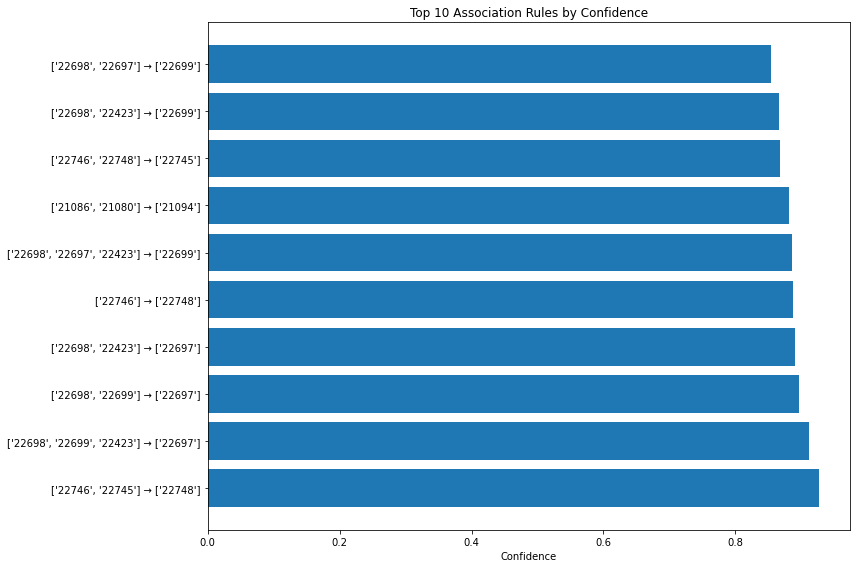

In [43]:
# Visualize top association rules
top_rules = association_rules.orderBy(col("confidence").desc()).limit(10).toPandas()

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_rules)), top_rules['confidence'])
plt.yticks(range(len(top_rules)), [f"{ant} → {cons}" for ant, cons in zip(top_rules['antecedent'], top_rules['consequent'])])
plt.xlabel('Confidence')
plt.title('Top 10 Association Rules by Confidence')
plt.tight_layout()
plt.show()

## Summary of Insights

Clustering reveals five clusters. Cluster 4, in particular, represents group of churned customers that requires effort to recover retention. 

Random Forest performs better than Linear Regression for predicting future customer spending. Average Quantity of items purchased per order was revealed to be the most important predictor of a customer's lifetime value, followed by the total number of transactions and customer tenure.

Based on the results, Random Forest performs better than Logistic Regression at identifying churned customers. Therefore, Random Forest would be the preferred model. 

Among 36,969 multi-item transactions, product association patterns identifies strong product affinity patterns. The retail store can make use of the results to improve strategic product placements, bundlings, and marketings. 

## Recommendations

The retail store does have a significant percentage of customer base that are churned. To increase engagement from customers who have already interacted and made purchases with the store before but inactive after, the retail store can conduct campaigns such as providing one time discount offers to the churned customers to improve customer retention. <br>

Product association rules can be utilised by the retail store to strategise on grouping those products when making advertisements or displaying them on shelves to increase the potential revenue. <br>

Customer Lifetime Value predictions with Random Forest model allow the retail store to focus their marketing resources on customers that have high potential spending throughout the future. 

The summary of insights and recommendations overall can help the retail store conduct personalize marketing campaigns, improve customer loyalty and retention to improve the quality of life of customers and minimize environmental impact from wasteful mass marketing practices to increase revenue and build sustainable business models.

## Algorithm References

1. eminecerit. (2022). RFM vs. K-Means in Customer Segmentation. Kaggle. https://www.kaggle.com/code/eminecerit/rfm-vs-k-means-in-customer-segmentation
2. VectorAssembler — PySpark 3.5.3 documentation. (2024). Apache.org. https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.htmlhttps://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.html